# Data Validity Testing

### Imports and Notebook Settings


In [44]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [45]:
import os 
import re
from pathlib import Path

In [46]:
import pandas as pd
import numpy as np 

import matplotlib.pyplot as plt
# import seaborn as sns 
import plotly.express as px
import pprint 

In [47]:
ROOT = Path.cwd().parent

In [48]:
style_path = ( ROOT 
              / 'notebooks' 
              / 'styler.mplstyle'
              )
plt.style.use(style_path)

## GDELT Articles

### Records

In [49]:
data_path = (
    ROOT
    / "data"
    / "silver"
    / "source=gdelt"
    / "records.parquet"
)

df = pd.read_parquet(data_path)

In [50]:
df.columns

Index(['record_id', 'source', 'source_type', 'title', 'text', 'published_at',
       'retrieved_at', 'url', 'region', 'categories', 'metadata', 'raw'],
      dtype='object')

In [51]:
df.head()

,record_id,source,source_type,title,text,published_at,retrieved_at,url,region,categories,metadata,raw
0,gdelt::20260723121500-318,gdelt,api,"Power outages, downed trees follow 5.6 inches ...",,2020-09-09 12:52:00+00:00,2026-07-23 15:17:55.949775+00:00,https://www.coloradodaily.com/2020/09/09/chanc...,US,"[SHORTAGE, MANMADE_DISASTER, MANMADE_DISASTER_...","{'source_common_name': 'coloradodaily.com', 'p...","{'GKGRECORDID': '20260723121500-318', 'DATE': ..."
1,gdelt::20260723083000-499,gdelt,api,DeBary graduates new class of Citizens Academy,,2026-07-02 10:20:00+00:00,2026-07-23 15:17:55.942160+00:00,https://www.daytonatimes.com/community/debary-...,None,"[WB_1675_GRADUATION, WB_855_LABOR_MARKETS, WB_...","{'source_common_name': 'daytonatimes.com', 'pu...","{'GKGRECORDID': '20260723083000-499', 'DATE': ..."
2,gdelt::20260717221500-1028,gdelt,api,What to Expect From Duke Energy's Next Quarter...,,2026-07-16 14:31:00+00:00,2026-07-23 15:16:43.113876+00:00,https://finance.yahoo.com/energy/articles/expe...,US,"[ENV_NATURALGAS, TAX_FNCACT, TAX_FNCACT_ANALYS...","{'source_common_name': 'yahoo.com', 'published...","{'GKGRECORDID': '20260717221500-1028', 'DATE':..."
3,gdelt::20260717121500-256,gdelt,api,Michigan AG Dana Nessel visits Kalamazoo to ad...,,2026-07-16 20:46:00+00:00,2026-07-23 15:16:43.100219+00:00,https://wsbt.com/news/regional/michigan-attorn...,CA,"[TRIAL, TAX_FNCACT, TAX_FNCACT_ATTORNEY, TAX_E...","{'source_common_name': 'wsbt.com', 'published_...","{'GKGRECORDID': '20260717121500-256', 'DATE': ..."
4,gdelt::20260717004500-871,gdelt,api,Planned electrical work in Missaukee reschedul...,,2026-07-16 21:00:00+00:00,2026-07-23 15:16:43.095359+00:00,https://www.cadillacnews.com/news/planned-elec...,None,[AFFECT],"{'source_common_name': 'cadillacnews.com', 'pu...","{'GKGRECORDID': '20260717004500-871', 'DATE': ..."


In [52]:
df['metadata'].iloc[0]

{'source_common_name': 'coloradodaily.com',
 'published_at': {'source': 'page_metadata', 'precision': 'second'},
 'organizations': array(['university hill', 'xcel energy', 'twitter',
        'national weather service boulder', 'court strong'], dtype=object),
 'persons': array(['savannah weigand', 'craig eicher', 'hunter arbuckle',
        'don mcghee', 'pete lockett', 'polly b murray', 'polly murray',
        'evan direnzo', 'savannah wiegand', 'michelle aguayo'],
       dtype=object),
 'locations': array(['US', 'US-USCO', 'USCO'], dtype=object),
 'tone': '-1.8640350877193,1.20614035087719,3.07017543859649,4.27631578947368,22.9166666666667,0.43859649122807,886',
 'filter': {'theme_match': False,
  'organization_match': True,
  'location_match': False,
  'match_count': None}}

In [53]:
len(df)

316

In [54]:
df["url"].isna().mean()

np.float64(0.0)

In [55]:
dup_rate = df["url"].duplicated().mean()
print(f"{dup_rate:.2%}")

0.00%


In [56]:
from urllib.parse import urlparse

df["domain"] = df["url"].apply(
    lambda x: urlparse(x).netloc
)

df["domain"].value_counts().head(30)

domain
www.themarketsdaily.com       16
www.dailypolitical.com        12
finance.yahoo.com              8
www.journal-news.com           7
www.daytondailynews.com        7
www.yahoo.com                  7
www.tickerreport.com           7
www.wral.com                   6
www.springfieldnewssun.com     6
cbs2iowa.com                   5
www.prnewswire.com             5
www.wbtv.com                   4
www.wsoctv.com                 4
wwmt.com                       4
www.wnem.com                   3
www.theitem.com                3
www.thegazette.com             3
www.fool.com                   3
www.fox19.com                  3
www.wbrz.com                   3
www.orlandosentinel.com        2
www.timescall.com              2
www.magnoliareporter.com       2
thebulletin.org                2
www.fox13news.com              2
fox4beaumont.com               2
www.dailykos.com               2
www.fortmorgantimes.com        2
www.wunc.org                   2
www.whqr.org                   2
Nam

In [57]:
df["title"].ne('').mean()

np.float64(1.0)

In [58]:
df["title_length"] = (
    df["title"]
    .fillna("")
    .str.len()
)

df["title_length"].describe()

count    316.000000
mean      75.844937
std       21.764643
min       16.000000
25%       62.750000
50%       76.500000
75%       86.000000
max      193.000000
Name: title_length, dtype: float64

In [59]:
from collections import Counter
import re

words = []

for title in df["title"].dropna():
    words.extend(
        re.findall(r"\b[a-z]+\b", title.lower())
    )

Counter(words).most_common(50)

[('to', 88),
 ('in', 82),
 ('power', 71),
 ('energy', 59),
 ('the', 54),
 ('as', 47),
 ('for', 43),
 ('of', 37),
 ('and', 36),
 ('with', 31),
 ('states', 31),
 ('wind', 30),
 ('trump', 28),
 ('michigan', 27),
 ('residents', 27),
 ('air', 27),
 ('developers', 27),
 ('s', 26),
 ('west', 25),
 ('quality', 25),
 ('buyouts', 25),
 ('shake', 25),
 ('offshore', 25),
 ('industry', 25),
 ('hope', 25),
 ('stay', 25),
 ('game', 25),
 ('wildfire', 23),
 ('deal', 23),
 ('after', 23),
 ('hazardous', 22),
 ('smoke', 22),
 ('blankets', 22),
 ('poor', 22),
 ('duke', 21),
 ('nyse', 18),
 ('county', 17),
 ('a', 16),
 ('electric', 16),
 ('storms', 16),
 ('trees', 14),
 ('new', 14),
 ('on', 14),
 ('rate', 14),
 ('company', 14),
 ('lines', 14),
 ('july', 13),
 ('more', 13),
 ('without', 13),
 ('shares', 13)]

In [60]:
df.iloc[0]["categories"]

array(['SHORTAGE', 'MANMADE_DISASTER', 'MANMADE_DISASTER_POWER_OUTAGES',
       'POWER_OUTAGE', 'CRISISLEX_T01_CAUTION_ADVICE',
       'UNGP_FORESTS_RIVERS_OCEANS', 'TAX_FNCACT',
       'TAX_FNCACT_METEOROLOGIST', 'AFFECT', 'TAX_FNCACT_SPOKESPERSON',
       'CRISISLEX_T04_INFRASTRUCTURE', 'TAX_FNCACT_MANAGER',
       'CRISISLEX_CRISISLEXREC', 'TAX_WORLDMAMMALS',
       'TAX_WORLDMAMMALS_DOG',
       'WB_1458_HEALTH_PROMOTION_AND_DISEASE_PREVENTION',
       'WB_1462_WATER_SANITATION_AND_HYGIENE', 'WB_635_PUBLIC_HEALTH',
       'WB_621_HEALTH_NUTRITION_AND_POPULATION',
       'TAX_FNCACT_PHOTOGRAPHER', 'NATURAL_DISASTER',
       'NATURAL_DISASTER_ICY', 'ENV_FORESTRY', 'WB_436_FORESTRY',
       'WB_1979_NATURAL_RESOURCE_MANAGEMENT',
       'WB_435_AGRICULTURE_AND_FOOD_SECURITY', 'MEDIA_SOCIAL',
       'MEDIA_MSM', 'TAX_FNCACT_REPORTER', 'TAX_FNCACT_LANDLORD',
       'EDUCATION', 'SOC_POINTSOFINTEREST',
       'SOC_POINTSOFINTEREST_UNIVERSITY', 'MANMADE_DISASTER_IMPLIED',
       'SOC_POINT

In [61]:
df.iloc[0]["metadata"]

{'source_common_name': 'coloradodaily.com',
 'published_at': {'source': 'page_metadata', 'precision': 'second'},
 'organizations': array(['university hill', 'xcel energy', 'twitter',
        'national weather service boulder', 'court strong'], dtype=object),
 'persons': array(['savannah weigand', 'craig eicher', 'hunter arbuckle',
        'don mcghee', 'pete lockett', 'polly b murray', 'polly murray',
        'evan direnzo', 'savannah wiegand', 'michelle aguayo'],
       dtype=object),
 'locations': array(['US', 'US-USCO', 'USCO'], dtype=object),
 'tone': '-1.8640350877193,1.20614035087719,3.07017543859649,4.27631578947368,22.9166666666667,0.43859649122807,886',
 'filter': {'theme_match': False,
  'organization_match': True,
  'location_match': False,
  'match_count': None}}

In [62]:
sample = df.sample(
    100,
    random_state=42
)

In [63]:
sample[
    ["title", "url"]
].to_csv(
    "gdelt_review.csv",
    index=False
)

In [64]:
daily_counts = (
    df.groupby(
        pd.to_datetime(df["published_at"]).dt.date
    )
    .size()
)

Text(0, 0.5, 'Article Counts')

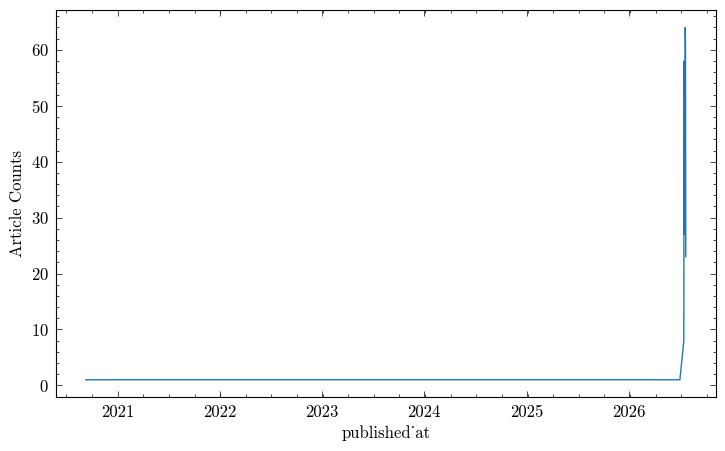

In [65]:
plt.figure(figsize=(8, 5))
daily_counts.plot()

plt.ylabel('Article Counts')

In [66]:
from collections import Counter
import json

org_counter = Counter()

for metadata in df["metadata"].dropna():
    try:
        data = json.loads(metadata) if isinstance(metadata, str) else metadata

        organizations = data.get("organizations", [])

        if organizations:
            org_counter.update(organizations)

    except Exception:
        continue

top_orgs = (
    pd.DataFrame(
        org_counter.most_common(50),
        columns=["organization", "count"]
    )
)

print(top_orgs)

              organization  count
0              duke energy     23
1         consumers energy      6
2                  entergy      5
3           alliant energy      4
4              xcel energy      1
5       centerpoint energy      1
6  american electric power      1


### Scraped Articles

In [67]:
data_path = (
    ROOT
    / "data"
    / "silver"
    / "source=gdelt"
    / "articles.parquet"
)

df = pd.read_parquet(data_path)

In [68]:
df.columns

Index(['record_id', 'source', 'source_type', 'title', 'text', 'published_at',
       'retrieved_at', 'url', 'region', 'categories', 'metadata', 'raw',
       'text_length'],
      dtype='object')

In [69]:
df['metadata'].iloc[0]

{'source_common_name': 'coloradodaily.com',
 'published_at': {'source': 'page_metadata', 'precision': 'second'},
 'organizations': array(['university hill', 'xcel energy', 'twitter',
        'national weather service boulder', 'court strong'], dtype=object),
 'persons': array(['savannah weigand', 'craig eicher', 'hunter arbuckle',
        'don mcghee', 'pete lockett', 'polly b murray', 'polly murray',
        'evan direnzo', 'savannah wiegand', 'michelle aguayo'],
       dtype=object),
 'locations': array(['US', 'US-USCO', 'USCO'], dtype=object),
 'tone': '-1.8640350877193,1.20614035087719,3.07017543859649,4.27631578947368,22.9166666666667,0.43859649122807,886',
 'filter': {'theme_match': False,
  'organization_match': True,
  'location_match': False,
  'match_count': None},
 'scraping': {'status': 'success',
  'success': True,
  'status_code': 200.0,
  'error_type': None,
  'error_message': None,
  'fetch_method': 'aiohttp',
  'fallback_used': False,
  'extractor': 'trafilatura_after_

In [70]:
df["has_precise_published_at"] = df["metadata"].apply(
    lambda x: x.get("has_precise_published_at", False)
)
df["precise_published_at_source"] = df["metadata"].apply(
    lambda x: x.get("published_at_source", None)
)

In [71]:
df[['published_at', 'has_precise_published_at', 'precise_published_at_source']]

,published_at,has_precise_published_at,precise_published_at_source
0,2020-09-09 12:52:26+00:00,False,None
1,2026-07-02 10:20:00+00:00,False,None
2,2026-07-16 20:46:28+00:00,False,None
3,2026-07-16 21:00:00+00:00,False,None
4,2026-07-16 21:41:30+00:00,False,None
...,...,...,...
311,2026-07-23 12:21:34+00:00,False,None
312,2026-07-23 17:30:38+00:00,False,None
313,2026-07-23 11:03:29.697000+00:00,False,None
314,2026-07-23 05:00:00+00:00,False,None


In [72]:
df["has_precise_published_at"].mean()

np.float64(0.0)

In [73]:
df.loc[df['has_precise_published_at'], 'precise_published_at_source'].value_counts()

Series([], Name: count, dtype: int64)

In [74]:
df['published_at'].min()

Timestamp('2020-09-09 12:52:26+0000', tz='UTC')

In [75]:
df['published_at'].max()

Timestamp('2026-07-23 17:30:38+0000', tz='UTC')

In [76]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 316 entries, 0 to 315
Data columns (total 15 columns):
 #   Column                       Non-Null Count  Dtype              
---  ------                       --------------  -----              
 0   record_id                    316 non-null    object             
 1   source                       316 non-null    object             
 2   source_type                  316 non-null    object             
 3   title                        316 non-null    object             
 4   text                         316 non-null    object             
 5   published_at                 316 non-null    datetime64[ns, UTC]
 6   retrieved_at                 316 non-null    datetime64[ns, UTC]
 7   url                          316 non-null    object             
 8   region                       276 non-null    object             
 9   categories                   316 non-null    object             
 10  metadata                     316 non-null    object    

In [77]:
(
    df["success"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

KeyError: 'success'

In [ ]:
(
    (df["scrape_status"].value_counts() / len(df))
    .mul(100)
    .round(2)
)

scrape_status
success             66.46
not_found           11.46
playwright_error     7.28
rate_limited         5.14
unknown              3.92
server_error         3.22
client_error         1.57
connection_error     0.43
parse_failed         0.36
http_error           0.16
Name: count, dtype: float64

In [ ]:
(
    df.groupby("error_type")
      .size()
      .sort_values(ascending=False)
)

error_type
not_found           3381
playwright_error    2146
rate_limited        1517
unknown             1155
server_error         950
client_error         463
connection_error     126
parse_failed         107
http_error            46
dtype: int64

In [ ]:
(
    df.groupby("status_code")
      .size()
      .sort_values(ascending=False)
)

status_code
200.0    19654
404.0     3381
429.0     1517
526.0      861
500.0       76
307.0       29
410.0       24
202.0       23
406.0       22
502.0        8
503.0        5
dtype: int64

In [ ]:
df["text_length"].describe()

count    29490.000000
mean      2490.842455
std       2645.339735
min          0.000000
25%          0.000000
50%       1709.500000
75%       4379.000000
max       8000.000000
Name: text_length, dtype: float64

In [ ]:
from urllib.parse import urlparse

df["domain"] = (
    df["url"]
    .apply(lambda x: urlparse(x).netloc)
)

In [ ]:
(
    df.groupby("domain")["success"]
      .mean()
      .sort_values()
)

domain
newschannel20.com         0.0
www.khou.com              0.0
www.kgw.com               0.0
www.kens5.com             0.0
www.kdrv.com              0.0
                         ... 
790waeb.iheart.com        1.0
800wvhu.iheart.com        1.0
925maxima.com             1.0
1025kiss.com              1.0
1019bigwaax.iheart.com    1.0
Name: success, Length: 2468, dtype: float64

In [ ]:
(
    df.groupby("domain")
      .size()
      .sort_values(ascending=False)
      .head(30)
)

domain
www.yahoo.com                   1483
www.themarketsdaily.com          822
www.dailypolitical.com           778
www.tickerreport.com             651
finance.yahoo.com                462
www.marketscreener.com           455
www.prnewswire.com               335
theenterpriseleader.com          321
www.modernreaders.com            312
www.nola.com                     243
www.mlive.com                    232
www.wkrb13.com                   228
www.fool.com                     226
markets.financialcontent.com     211
www.utilitydive.com              205
www.insidermonkey.com            176
wwmt.com                         167
www.wnem.com                     166
www.theadvocate.com              155
www.wwltv.com                    154
www.wsoctv.com                   153
www.denverpost.com               147
www.wzzm13.com                   143
www.renewableenergyworld.com     142
www.wbrz.com                     139
www.finanznachrichten.de         136
www.wfae.org                   

In [ ]:
sample = (
    df[df["success"]]
    .sample(50, random_state=42)
)

In [ ]:
sample['text']

15219    PINE ISLAND, Minn. — Google is building a 250,...
9929     MURPHY Thankful for a free dinner The free com...
22427    Dive Brief: - Overall U.S. generation M&A held...
16063    U.S. Sen. Jon Husted testifies remotely in ex-...
15412    President Trump highlighted the 2025 murder of...
19035    Urgency grows for home energy bill relief in M...
17199    Consumers Energy Customers Face Higher Bills W...
17286    Xcel Energy sending refunds to customers thank...
20947    Garbage can fire damages Fond du Lac house Pub...
22582    Life-Saving Winter Alert in Minnesota: What Yo...
20111    The small town of Carrboro, North Carolina is ...
24456    A sudden surge in tree planting across New Orl...
332      Severe Weather Forces Closures in Lake Charles...
22393    Southern US thaws from storm, but black ice ri...
12632    Meeting on Google’s planned Little Rock data c...
17509    LANSING, Mich. (WJRT) - Consumers Energy kicke...
2480     Funding available through Foundation for Appal.

## IEM AFOS

In [101]:
data_path = (
    ROOT
    / "data"
    / "silver"
    / "source=iem_afos"
    / "records.parquet"
)

df = pd.read_parquet(data_path)

In [87]:
df.columns

Index(['record_id', 'source', 'source_type', 'title', 'text', 'published_at',
       'retrieved_at', 'url', 'region', 'categories', 'metadata', 'raw'],
      dtype='object')

In [88]:
len(df)

3091

In [102]:
df.iloc[0]

record_id       iem::c33f919eae8dd6e63ac0070500da8ed91eed1d17d...
source                                                   iem_afos
source_type                                                   api
title                     LSR | KILX | 740 PM CDT Sun Apr 19 2026
text            310 NWUS53 KILX 200040 LSRILX Preliminary Loca...
published_at                            2026-04-20 00:40:00+00:00
retrieved_at                     2026-07-23 14:57:21.413657+00:00
url             https://mesonet.agron.iastate.edu/cgi-bin/afos...
region                                                        ILX
categories                         [weather, nws, iem, afos, lsr]
metadata        {'product_type': 'LSR', 'office': 'KILX', 'pil...
raw             310 \nNWUS53 KILX 200040\nLSRILX\n\nPreliminar...
Name: 0, dtype: object

In [103]:
df.columns

Index(['record_id', 'source', 'source_type', 'title', 'text', 'published_at',
       'retrieved_at', 'url', 'region', 'categories', 'metadata', 'raw'],
      dtype='object')

In [104]:
df["metadata"].iloc[20]

{'product_type': 'AFD',
 'office': 'KIND',
 'pil': 'AFDIND',
 'section_names': array(['KEY MESSAGES', 'FORECAST UPDATE', 'DISCUSSION', 'AVIATION',
        'WATCHES/WARNINGS/ADVISORIES'], dtype=object),
 'section_count': 5,
 'sections': '{"KEY MESSAGES": {"name": "KEY MESSAGES", "detail": null, "text": "- A Freeze Warning is in effect tonight into early Monday for the\\n  northern half of central Indiana; A Frost Advisory is in effect\\n  tonight for the remainder of central Indiana.\\n\\n- Warming trend beginning on Tuesday, with storm chances Tuesday\\n  night into Wednesday", "issued_at_text": null, "published_at": null}, "FORECAST UPDATE": {"name": "FORECAST UPDATE", "detail": null, "text": "Surface analysis this evening shows strong high pressure in place \\nover the upper midwest. This system was building southeast toward \\nIndiana. GOES19 shows a few lingering diurnal CU still waning across \\nCentral Indiana, but the overall clearing trend was underway. Gusty \\nwinds across th

In [98]:
df["source"].value_counts()

source
iem_afos    3091
Name: count, dtype: int64

In [99]:
df["product_type"] = df["metadata"].apply(
    lambda x: x.get("product_type")
)

df["product_type"].value_counts()

product_type
AFD    1362
LSR     988
HWO     429
SPS     201
NPW     111
Name: count, dtype: int64

In [ ]:
df["region"].value_counts()

region
IND    529
ILX    505
IWX    480
LSX    442
LOT    414
DVN    368
DMX    353
Name: count, dtype: int64

In [ ]:
(
    df.groupby(
        [
            pd.to_datetime(df["published_at"]).dt.date,
            "region"
        ]
    )
    .size()
    .unstack(fill_value=0)
)

region,DMX,DVN,ILX,IND,IWX,LOT,LSX
published_at,,,,,,,
2026-04-20,12,16,25,14,9,15,12
2026-04-21,7,11,17,10,9,9,9
2026-04-22,9,9,11,12,43,10,9
2026-04-23,12,9,18,9,19,8,9
2026-04-24,26,36,10,21,12,11,11
2026-04-25,6,9,10,17,9,8,9
2026-04-26,7,8,8,10,8,10,8
2026-04-27,9,24,31,43,53,62,38
2026-04-28,7,12,73,54,54,33,47


In [ ]:
df["text_length"] = (
    df["text"]
    .fillna("")
    .str.len()
)

(
    df.groupby("product_type")["text_length"]
      .describe()
)

,count,mean,std,min,25%,50%,75%,max
product_type,,,,,,,,
AFD,1362.0,660.530103,896.424764,72.0,260.0,362.0,523.0,6584.0
HWO,429.0,1543.522145,758.708869,285.0,1127.0,1410.0,1852.0,5941.0
LSR,988.0,612.261134,943.897759,335.0,379.0,408.0,466.0,8000.0
NPW,111.0,1425.513514,532.457303,385.0,1039.5,1344.0,1746.5,2797.0
SPS,201.0,1276.980100,248.755080,683.0,1100.0,1278.0,1440.0,2065.0


In [ ]:
weather_terms = [
    "snow",
    "ice",
    "lake effect",
    "thunderstorm",
    "tornado",
    "wind",
    "heat",
    "cold",
    "rain",
    "flood"
]

for term in weather_terms:
    count = (
        df["text"]
        .str.lower()
        .str.contains(term, na=False)
        .sum()
    )

    print(term, count)

snow 0
ice 1712
lake effect 0
thunderstorm 1298
tornado 266
wind 1202
heat 89
cold 398
rain 1019
flood 375


In [ ]:
winter_terms = (
    df["text"]
    .str.lower()
    .str.contains(
        "snow|ice|blizzard|freezing",
        regex=True,
        na=False,
    )
)

summer_terms = (
    df["text"]
    .str.lower()
    .str.contains(
        "heat|thunderstorm",
        regex=True,
        na=False,
    )
)

In [ ]:
monthly = (
    df.assign(
        winter=winter_terms,
        summer=summer_terms,
        month=pd.to_datetime(df["published_at"]).dt.month,
    )
    .groupby("month")[["winter", "summer"]]
    .sum()
)

print(monthly)

       winter  summer
month                
4         830     511
5         922     822


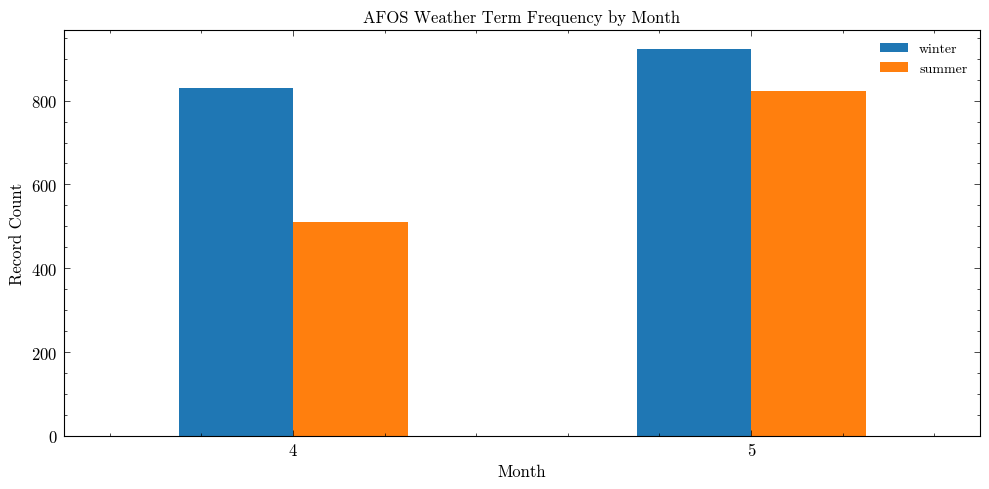

In [ ]:
import matplotlib.pyplot as plt

monthly.plot(
    kind="bar",
    figsize=(10, 5),
)

plt.title("AFOS Weather Term Frequency by Month")
plt.ylabel("Record Count")
plt.xlabel("Month")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()